In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler

In [2]:
df=pd.read_csv("pre_final_database.csv")

In [3]:
# df['company_size'] = pd.Categorical(df['company_size'], categories=['1-25', '26-100', '101-500', '500-1000', 'More than 1000'], ordered=True).codes

# df = pd.get_dummies(df, columns=['jobma_catcher_otype', 'per_sub_user'], prefix=['otype', 'subuser'], drop_first=True)
# df = df.astype({col: int for col in df.columns if df[col].dtype == 'bool'})

In [4]:
# scaler = RobustScaler()
# df_scaled = scaler.fit_transform(df)

In [5]:
df.describe()

,catcher_id,jobma_catcher_title,jobma_catcher_status,jobma_catcher_type,is_premium,jobma_verified,subscription_status,sub_user,live_interview_credit,pre_recorded_credit,...,credit_given,currency_val,times_of_subscription,kits_count,position_created,number_of_invitations,pitchers_counts,def_interview_counts,interview_counts,ai_interview_counts
count,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,...,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000
mean,4768.240369,0.234943,0.908663,0.922590,0.378188,0.999096,1.887864,279.376379,1.423505,3.383758,...,49.328269,1.977976,1.986616,2.605173,1.512751,8.709893,6.570266,3.347260,0.170194,0.013384
std,2431.388564,0.777744,0.301610,0.267265,0.484979,0.030061,0.317847,1927.332416,13.675515,135.205973,...,291.776292,8.306666,4.597021,128.021540,18.617189,102.554300,240.300559,37.065864,3.278246,0.903944
min,92.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2774.000000,0.000000,1.000000,1.000000,0.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4794.000000,0.000000,1.000000,1.000000,0.000000,1.000000,2.000000,5.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6914.000000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,103.000000,1.000000,1.000000,...,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,9445.000000,8.000000,1.000000,1.000000,1.000000,1.000000,2.000000,140000.000000,1000.000000,9999.990000,...,10000.000000,71.870000,238.000000,9504.000000,825.000000,3396.000000,17640.000000,1069.000000,150.000000,67.000000


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
catcher_id,5529.0,4768.240369,2.431389e+03,92.0,2774.00,4794.0,6914.0,9445.00
jobma_catcher_title,5529.0,0.234943,7.777441e-01,0.0,0.00,0.0,0.0,8.00
jobma_catcher_status,5529.0,0.908663,3.016102e-01,-1.0,1.00,1.0,1.0,1.00
jobma_catcher_type,5529.0,0.922590,2.672651e-01,0.0,1.00,1.0,1.0,1.00
is_premium,5529.0,0.378188,4.849787e-01,0.0,0.00,0.0,1.0,1.00
jobma_verified,5529.0,0.999096,3.006108e-02,0.0,1.00,1.0,1.0,1.00
subscription_status,5529.0,1.887864,3.178470e-01,0.0,2.00,2.0,2.0,2.00
sub_user,5529.0,279.376379,1.927332e+03,0.0,1.00,5.0,103.0,140000.00
live_interview_credit,5529.0,1.423505,1.367551e+01,0.0,1.00,1.0,1.0,1000.00
pre_recorded_credit,5529.0,3.383758,1.352060e+02,0.0,1.00,1.0,1.0,9999.99


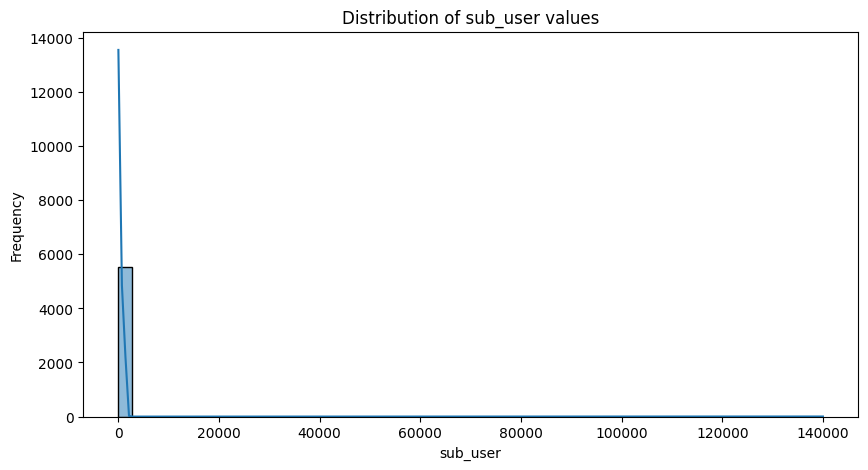

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['sub_user'].dropna(), bins=50, kde=True)
plt.title('Distribution of sub_user values')
plt.xlabel('sub_user')
plt.ylabel('Frequency')
plt.show()


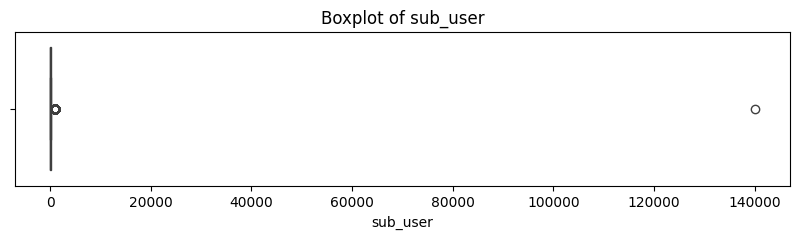

In [8]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['sub_user'])
plt.title('Boxplot of sub_user')
plt.show()


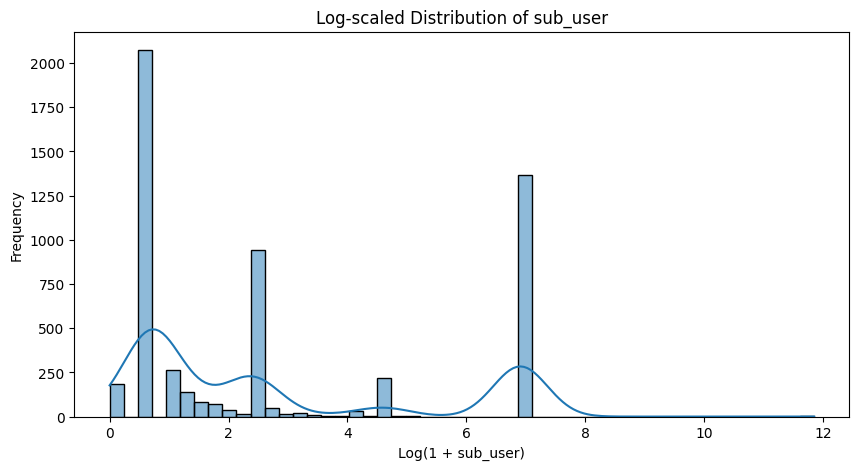

In [9]:
import numpy as np
#log scaled
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df['sub_user'].dropna()), bins=50, kde=True)
plt.title('Log-scaled Distribution of sub_user')
plt.xlabel('Log(1 + sub_user)')
plt.ylabel('Frequency')
plt.show()


<Axes: xlabel='sub_user', ylabel='count'>

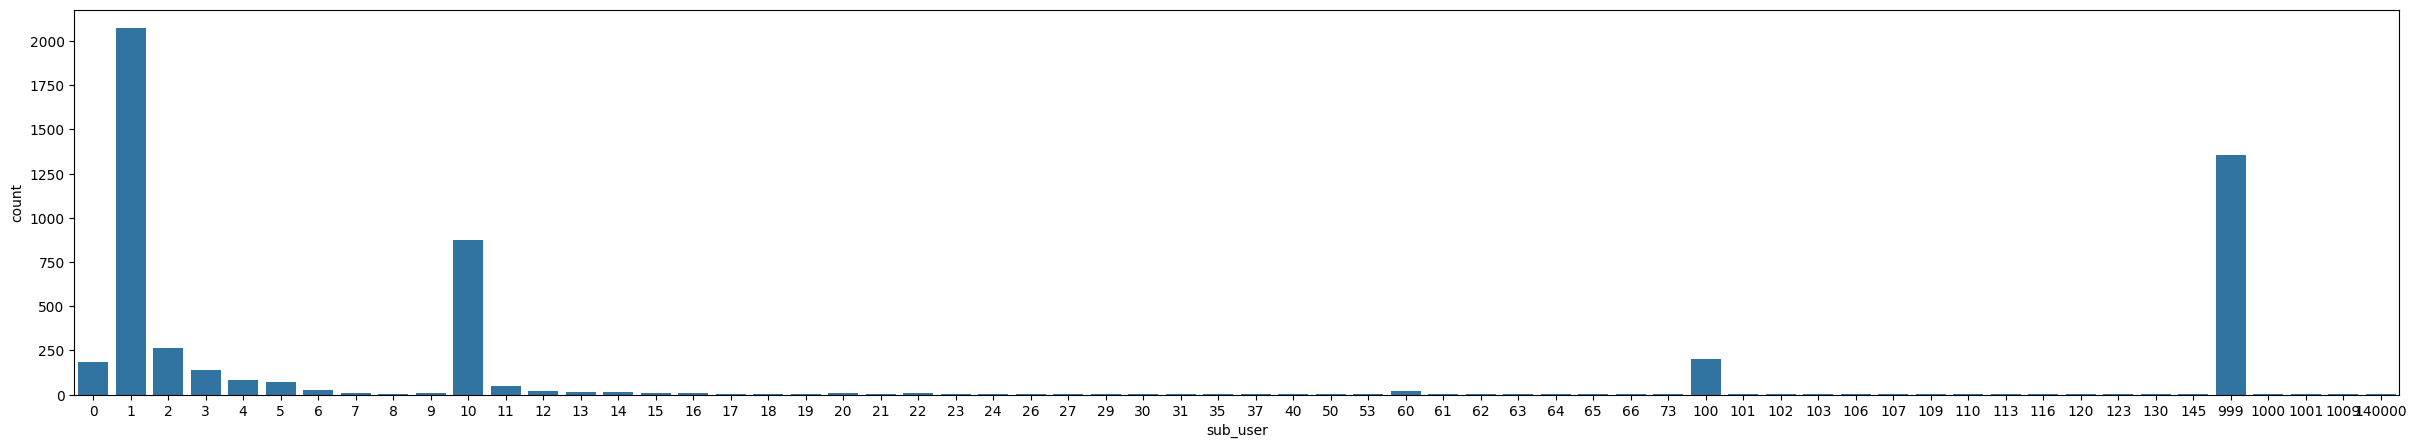

In [10]:
plt.figure(figsize=(30,5))
sns.countplot(x=df['sub_user'])

<Axes: xlabel='live_interview_credit', ylabel='count'>

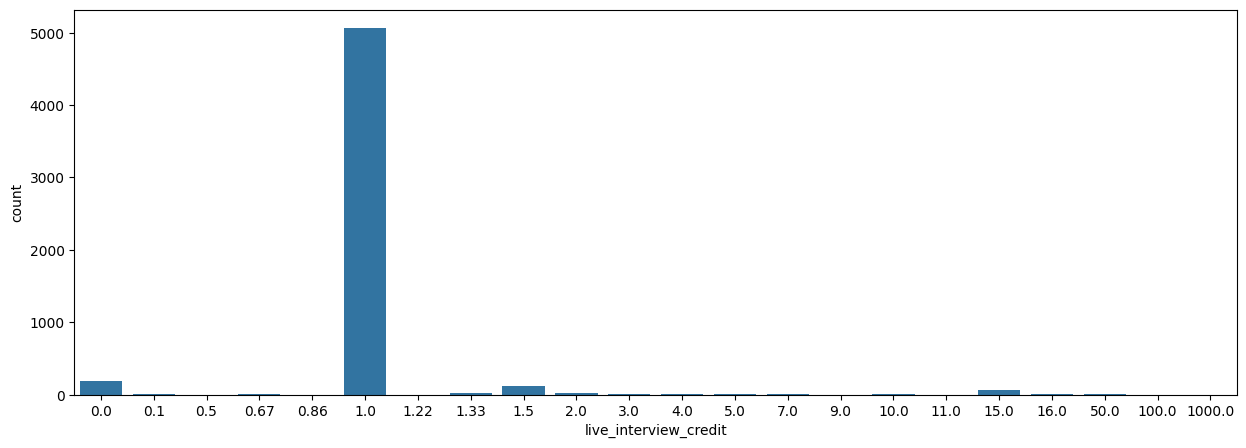

In [11]:
plt.figure(figsize=(15,5))
sns.countplot(x=df['live_interview_credit'])

<Axes: xlabel='pre_recorded_credit', ylabel='count'>

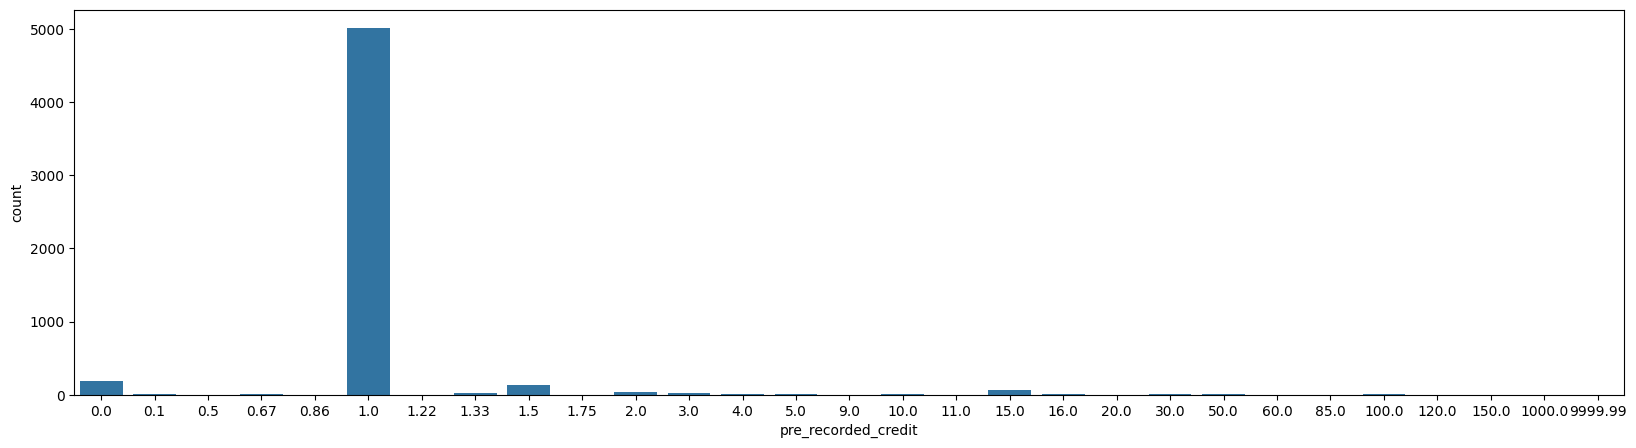

In [12]:
plt.figure(figsize=(20,5))
sns.countplot(x=df['pre_recorded_credit'])

<Axes: xlabel='credit_given', ylabel='count'>

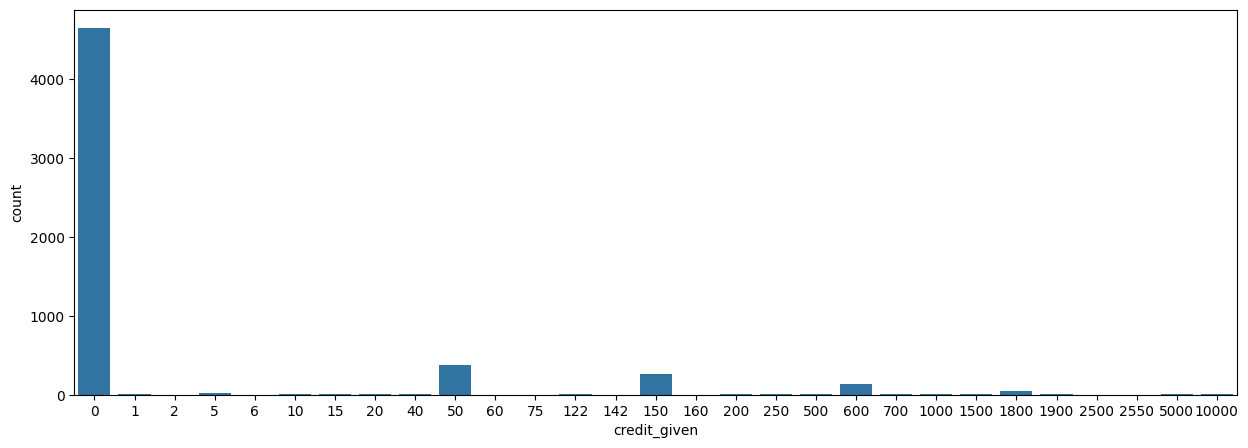

In [13]:
plt.figure(figsize=(15,5))
sns.countplot(x=df['credit_given'])

<Axes: xlabel='currency_val', ylabel='count'>

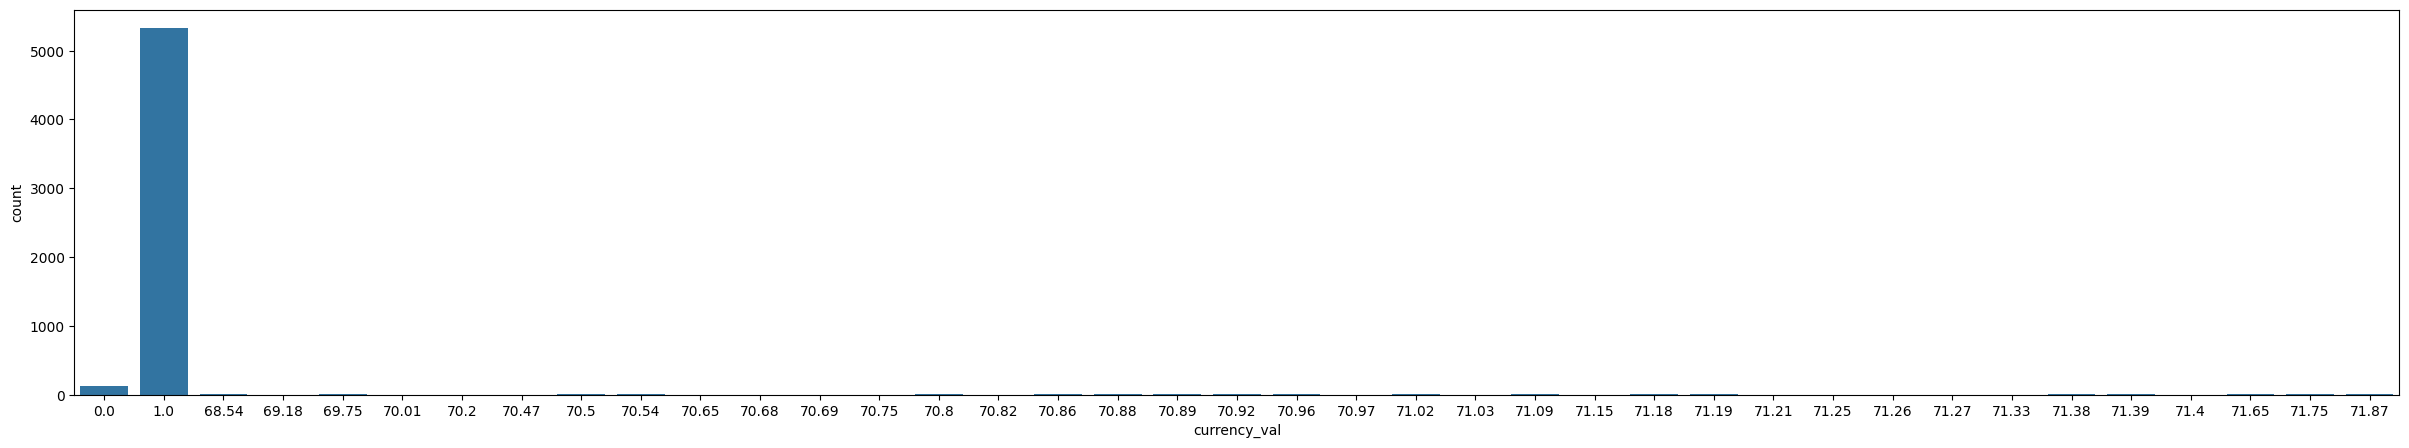

In [14]:
plt.figure(figsize=(30,5))
sns.countplot(x=df['currency_val'])

<Axes: xlabel='referral_credit', ylabel='count'>

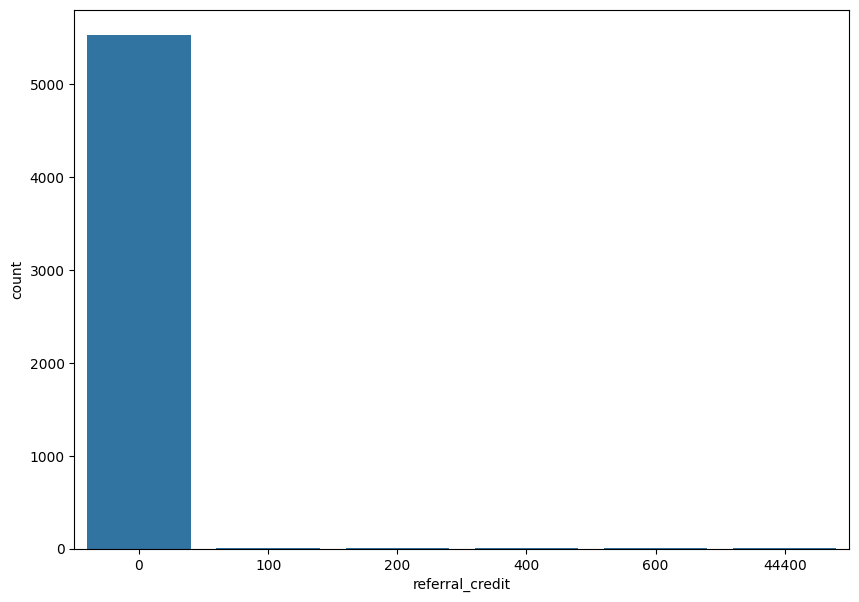

In [15]:
plt.figure(figsize=(10,7))
sns.countplot(x=df['referral_credit'])

<Axes: xlabel='jobma_catcher_title', ylabel='Count'>

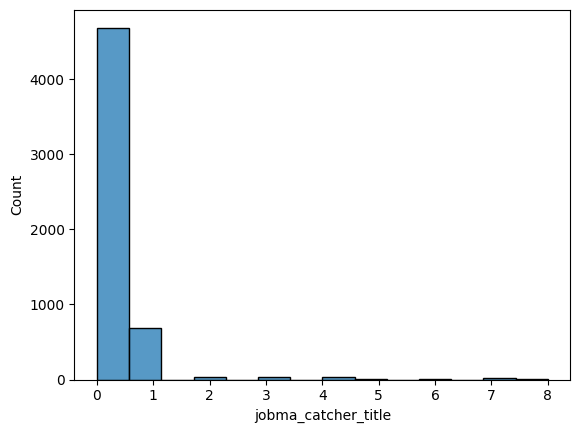

In [16]:
sns.histplot(data=df['jobma_catcher_title'])

<Figure size 1200x1000 with 0 Axes>

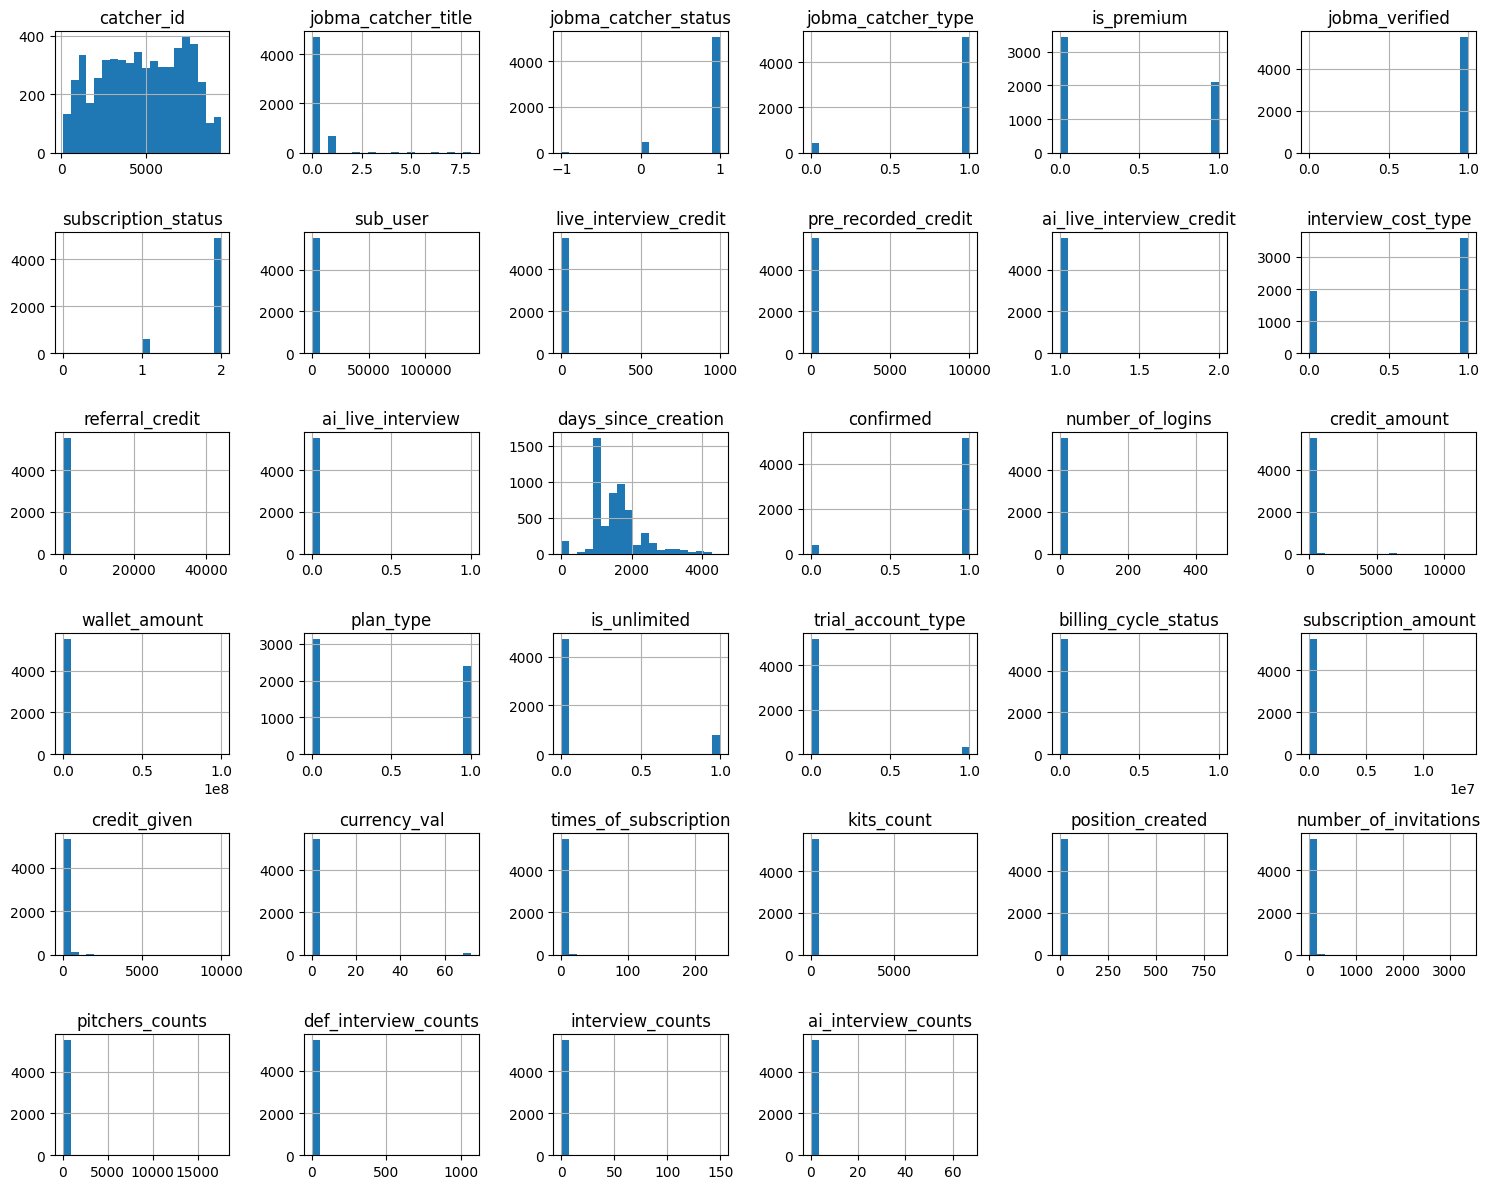

In [17]:
plt.figure(figsize=(12, 10))
df.hist(bins=20, figsize=(15, 12))
plt.tight_layout()
plt.show()

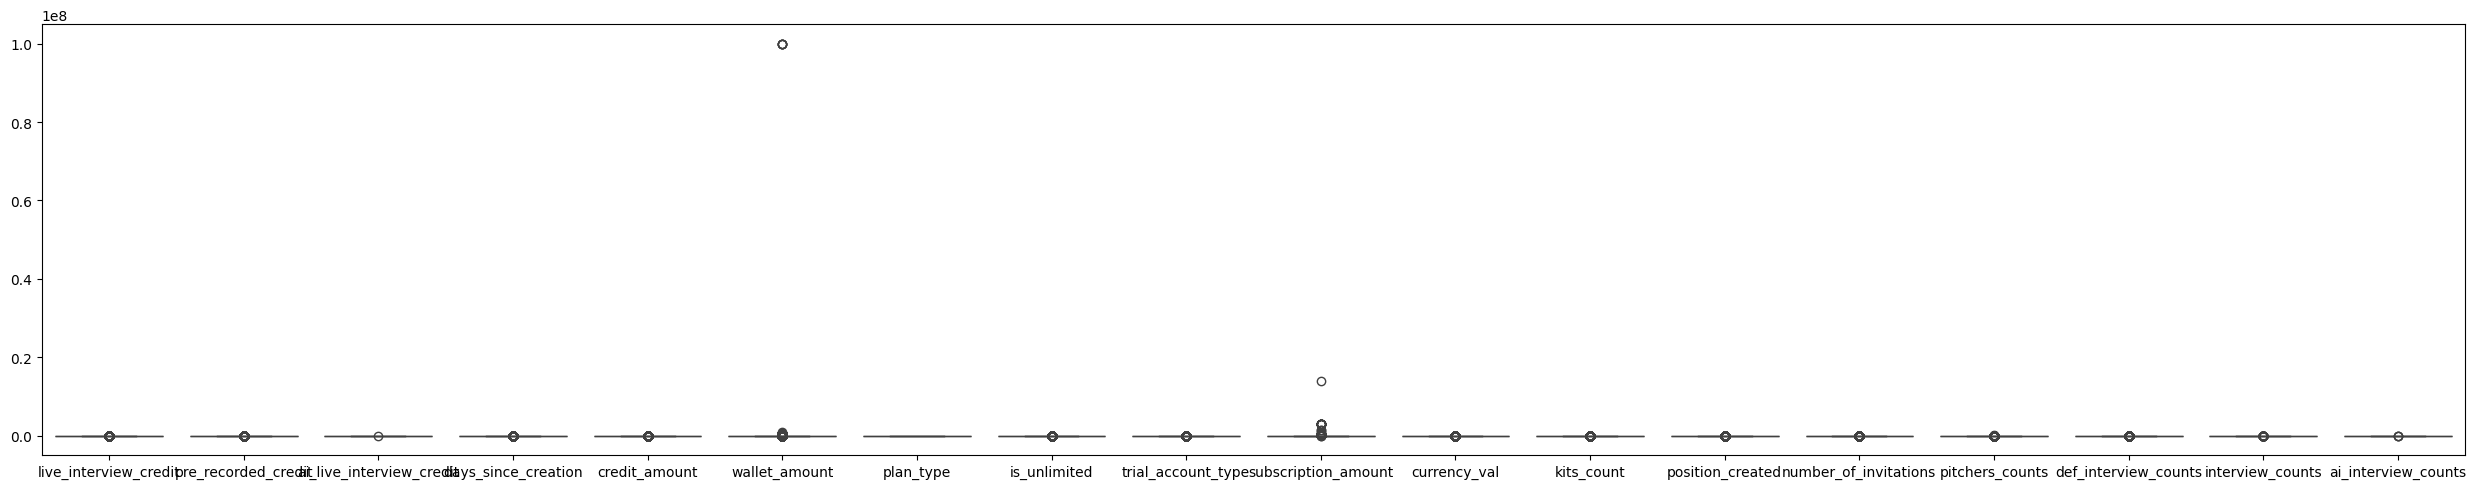

In [18]:
plt.figure(figsize=(25, 5))
numeric_cols = df.select_dtypes(include=['float64']).columns
sns.boxplot(data=df[numeric_cols])
plt.tight_layout()
plt.show()


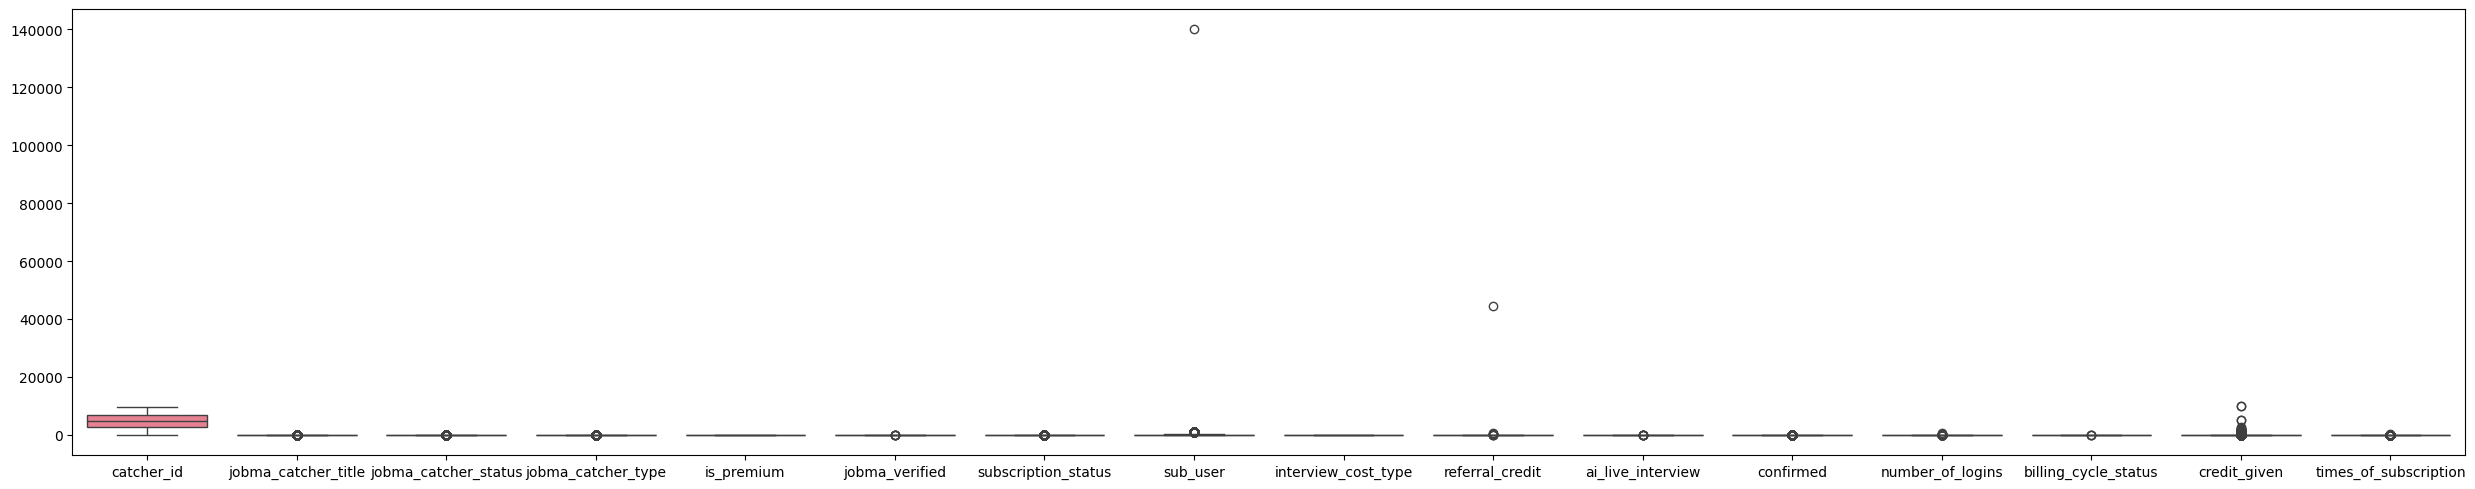

In [19]:
plt.figure(figsize=(25, 5))
numeric_cols = df.select_dtypes(include=['int64']).columns
sns.boxplot(data=df[numeric_cols])
plt.tight_layout()
plt.show()


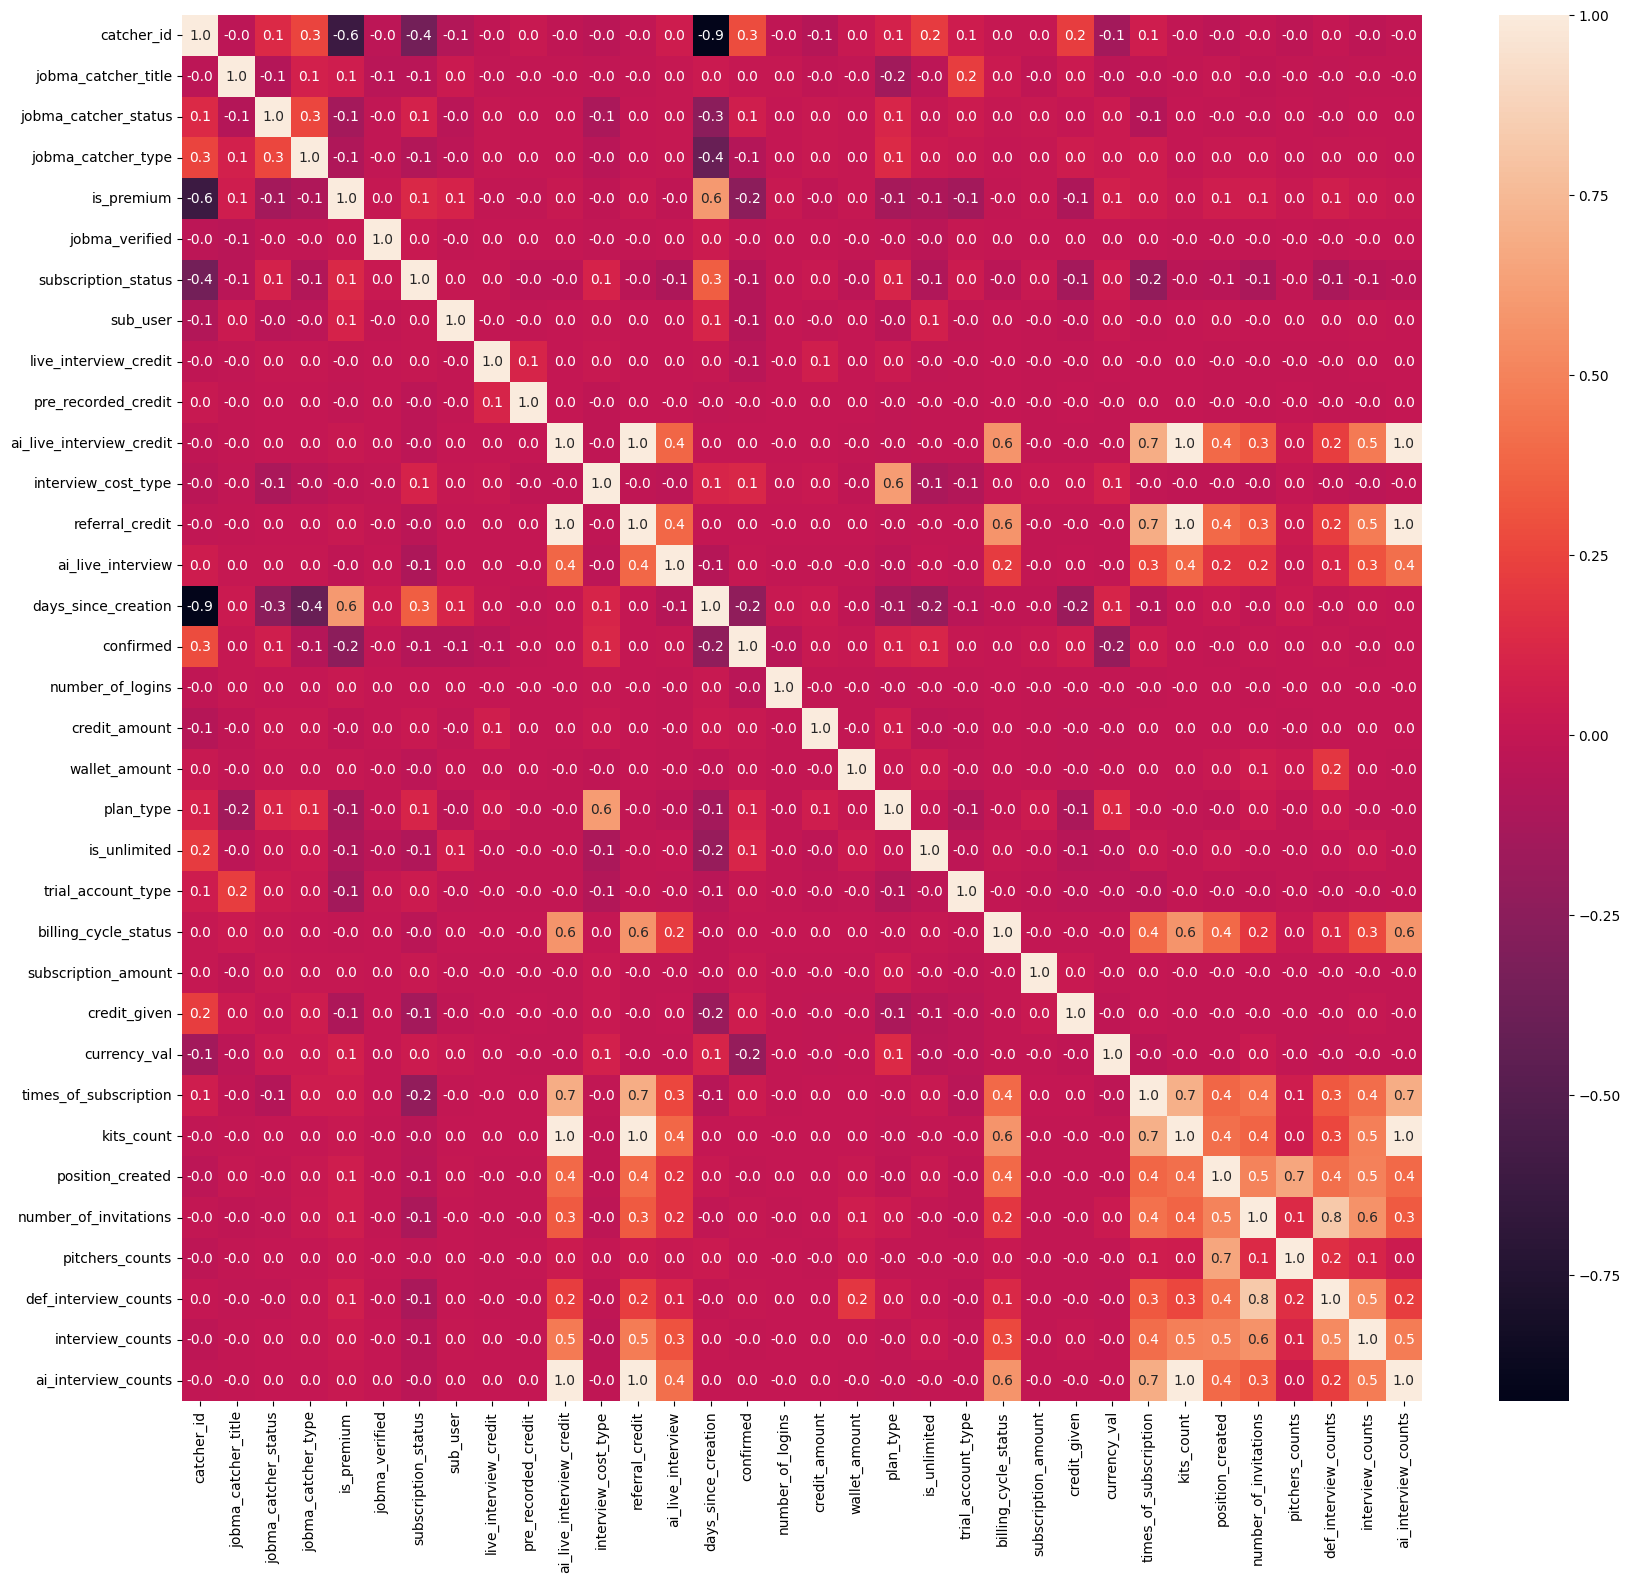

In [20]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=True, fmt='.1f')
plt.show()

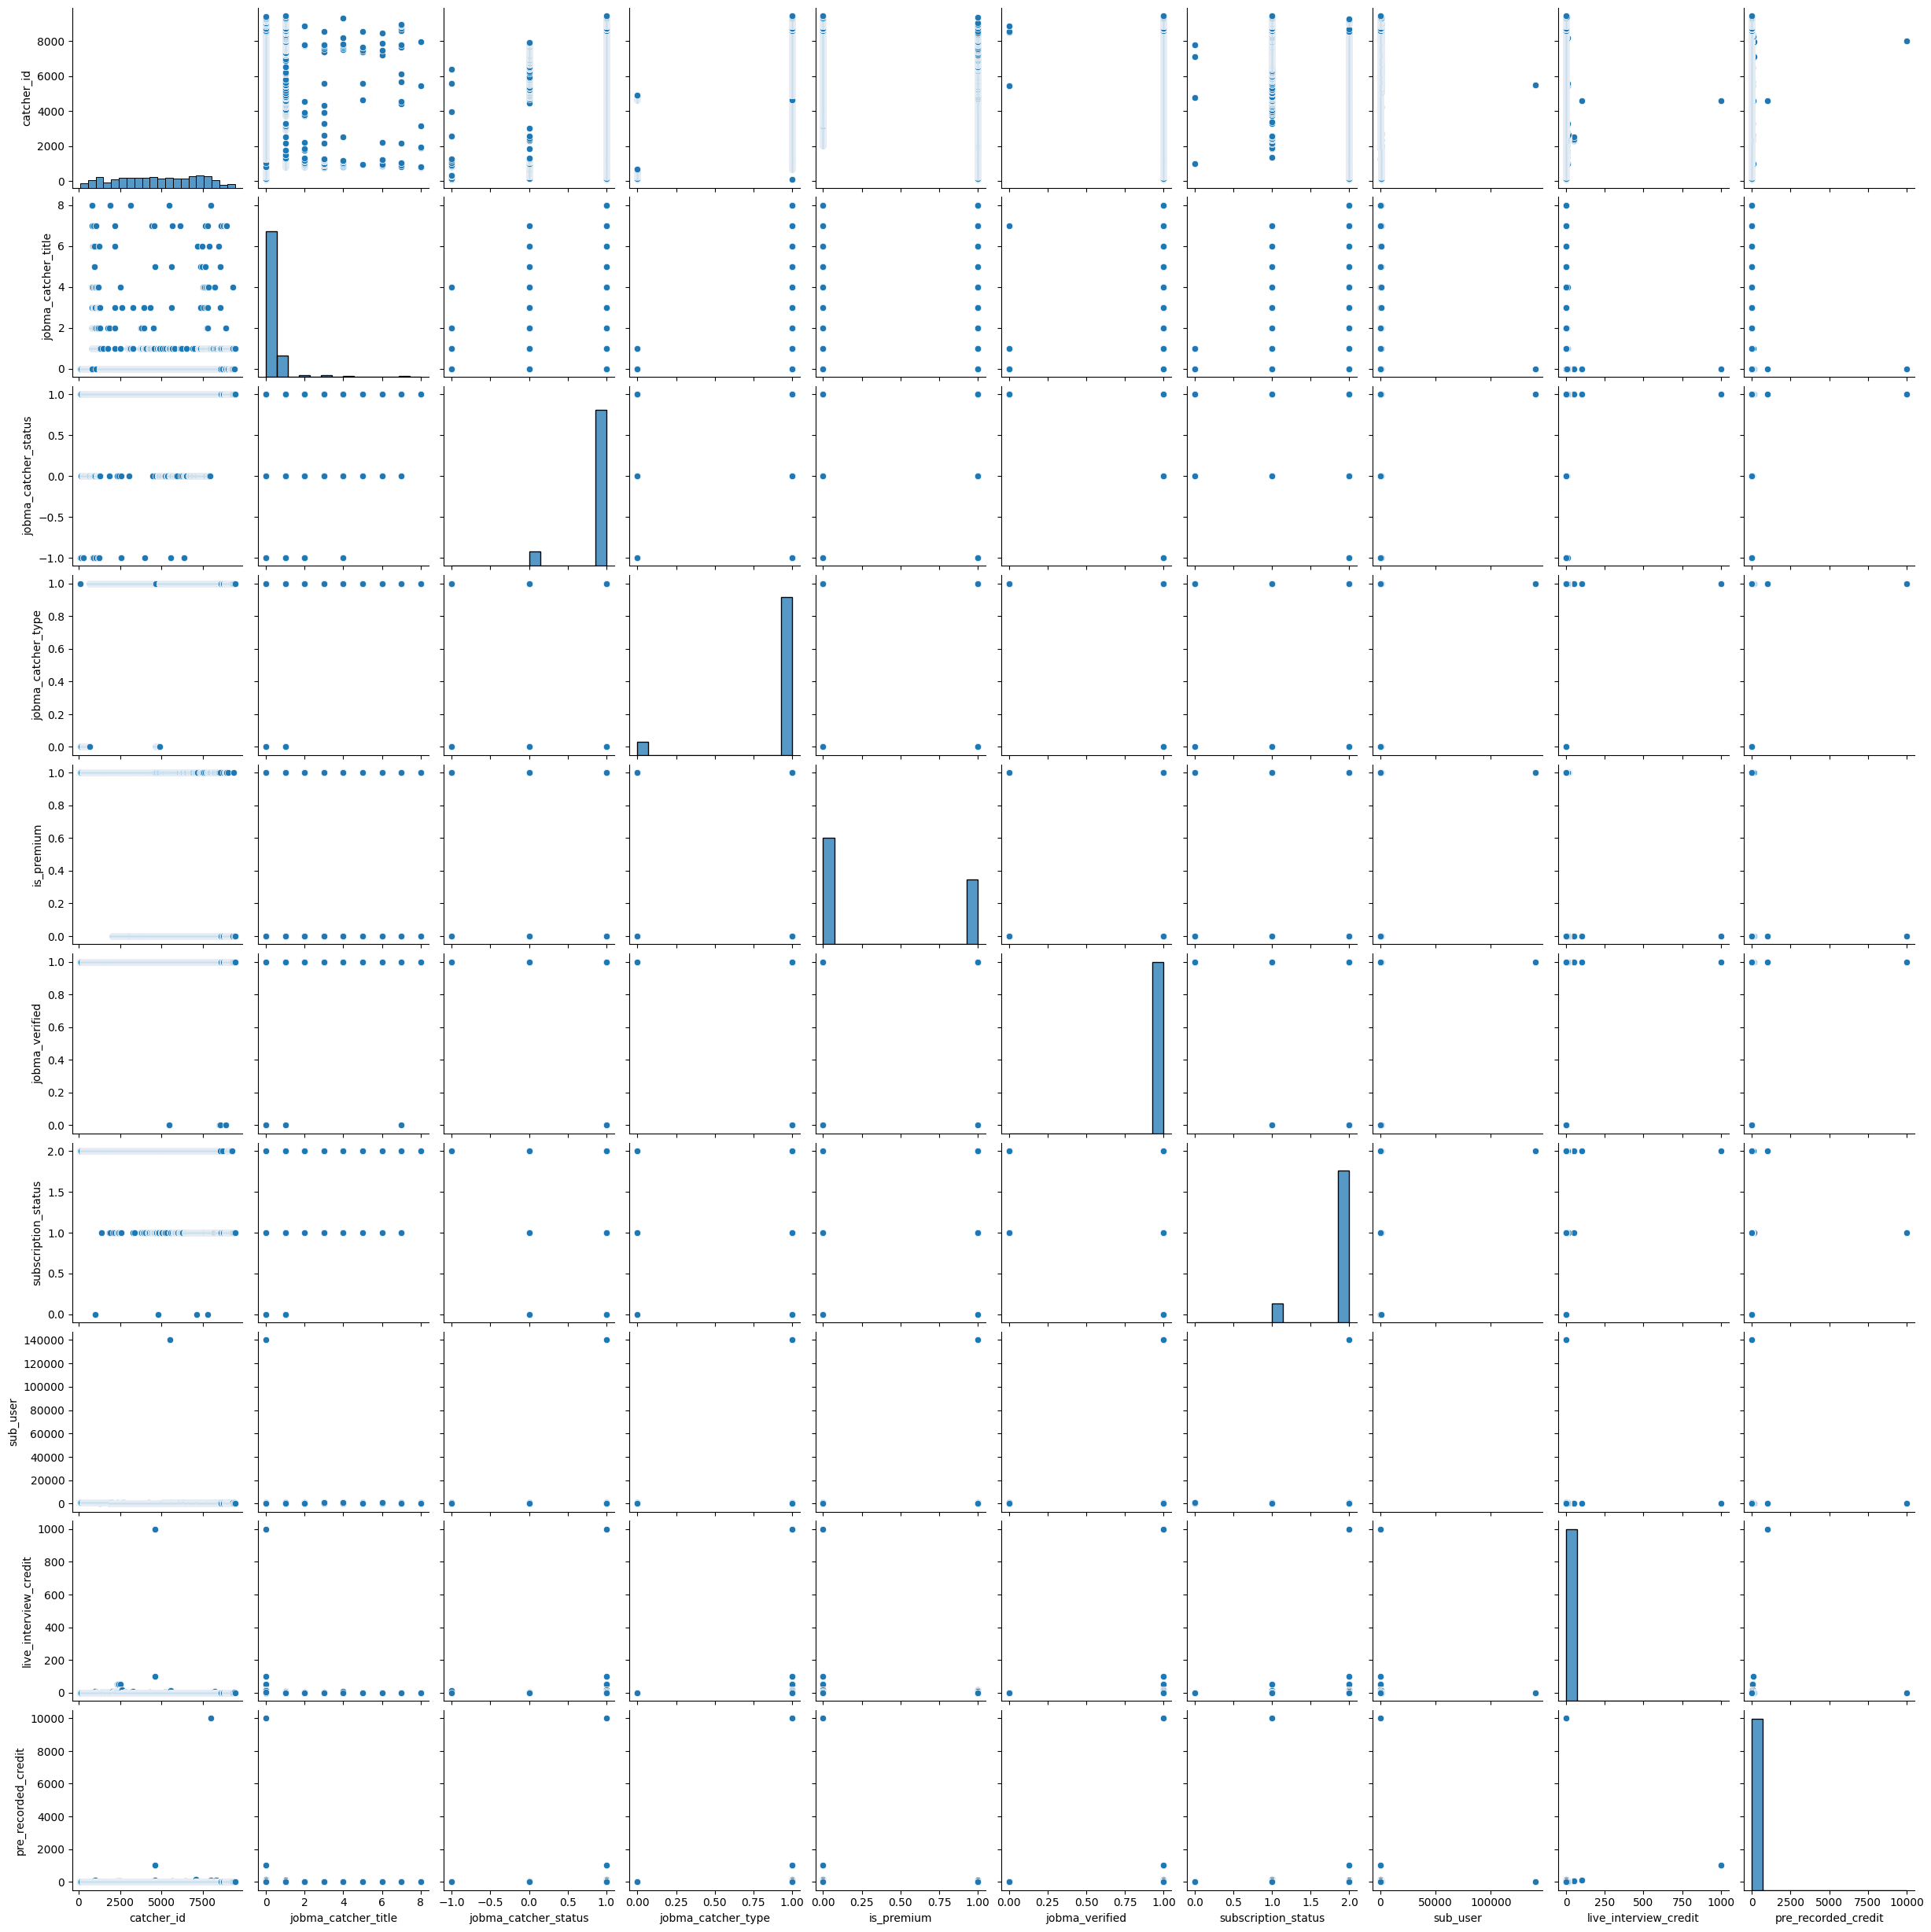

In [21]:
subset_cols = df.select_dtypes(include=['float64', 'int64']).columns[:10]
sns.pairplot(df[subset_cols], hue=None)
plt.show()

In [22]:
df.describe(include='all')

,catcher_id,jobma_catcher_title,jobma_catcher_otype,jobma_catcher_status,jobma_catcher_type,is_premium,jobma_verified,subscription_status,sub_user,per_sub_user,...,credit_given,currency_val,times_of_subscription,kits_count,position_created,number_of_invitations,pitchers_counts,def_interview_counts,interview_counts,ai_interview_counts
count,5529.000000,5529.000000,5529,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529,...,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000
unique,NaN,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5297,NaN,NaN,NaN,NaN,NaN,NaN,3098,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4768.240369,0.234943,NaN,0.908663,0.922590,0.378188,0.999096,1.887864,279.376379,NaN,...,49.328269,1.977976,1.986616,2.605173,1.512751,8.709893,6.570266,3.347260,0.170194,0.013384
std,2431.388564,0.777744,NaN,0.301610,0.267265,0.484979,0.030061,0.317847,1927.332416,NaN,...,291.776292,8.306666,4.597021,128.021540,18.617189,102.554300,240.300559,37.065864,3.278246,0.903944
min,92.000000,0.000000,NaN,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2774.000000,0.000000,NaN,1.000000,1.000000,0.000000,1.000000,2.000000,1.000000,NaN,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4794.000000,0.000000,NaN,1.000000,1.000000,0.000000,1.000000,2.000000,5.000000,NaN,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6914.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,2.000000,103.000000,NaN,...,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


<Axes: xlabel='jobma_catcher_status', ylabel='count'>

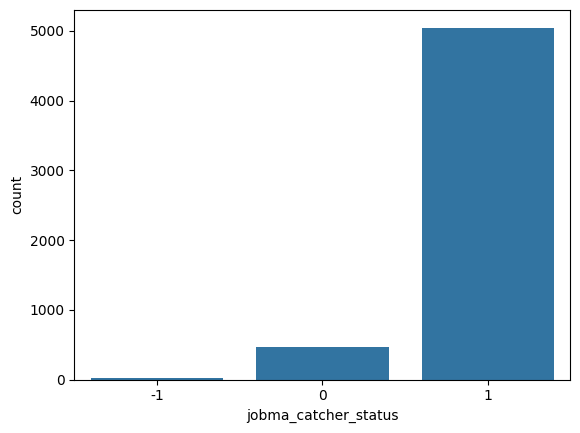

In [23]:
sns.countplot(x=df['jobma_catcher_status'])

<Axes: xlabel='jobma_catcher_otype', ylabel='count'>

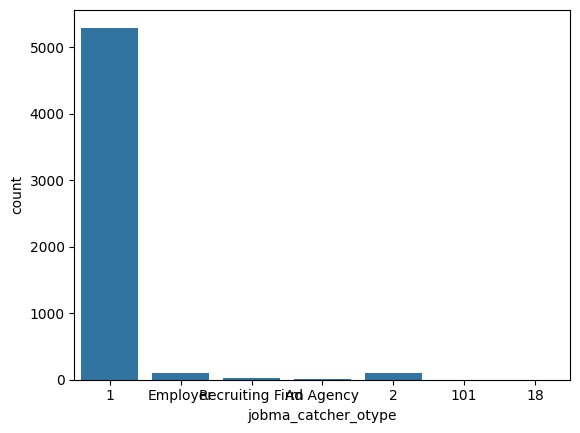

In [24]:
sns.countplot(x=df['jobma_catcher_otype'])

<Axes: xlabel='jobma_verified', ylabel='count'>

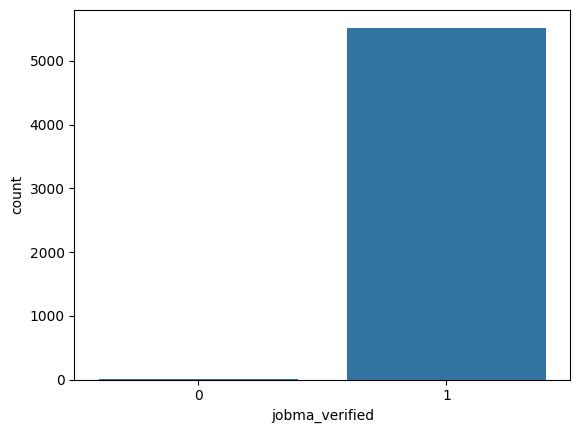

In [25]:
sns.countplot(x=df['jobma_verified'])

<Axes: xlabel='subscription_status', ylabel='count'>

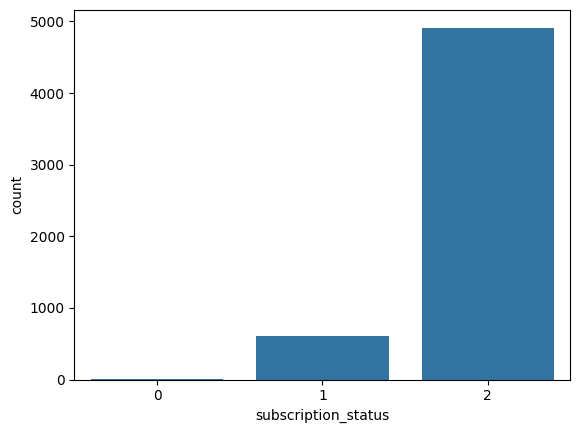

In [26]:
sns.countplot(x=df['subscription_status'])

<Axes: xlabel='company_size', ylabel='count'>

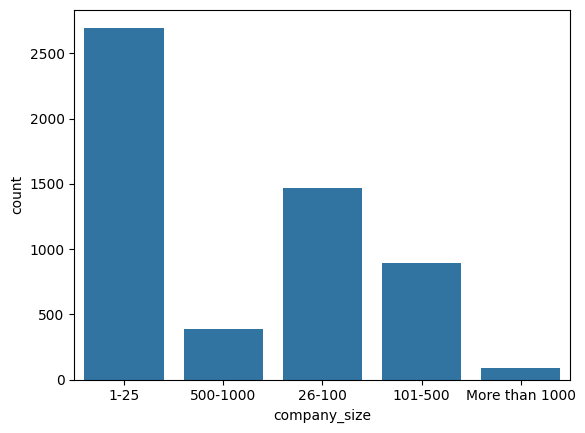

In [27]:
sns.countplot(x=df['company_size'])

<Axes: xlabel='plan_type', ylabel='count'>

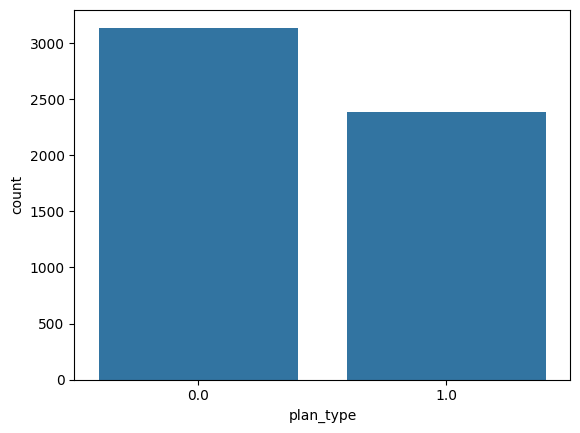

In [28]:
sns.countplot(x=df['plan_type'])

<Axes: xlabel='is_unlimited', ylabel='count'>

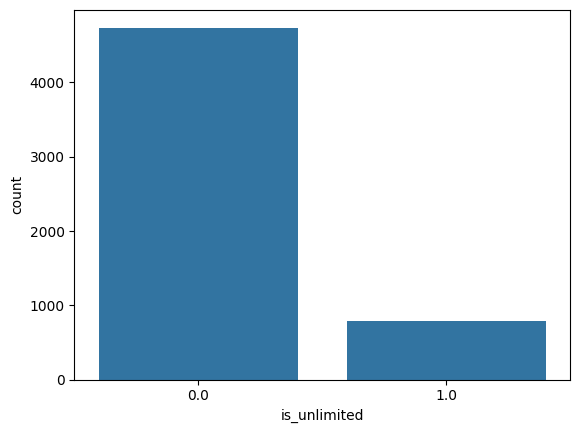

In [29]:
sns.countplot(x=df['is_unlimited'])

<Axes: xlabel='confirmed', ylabel='count'>

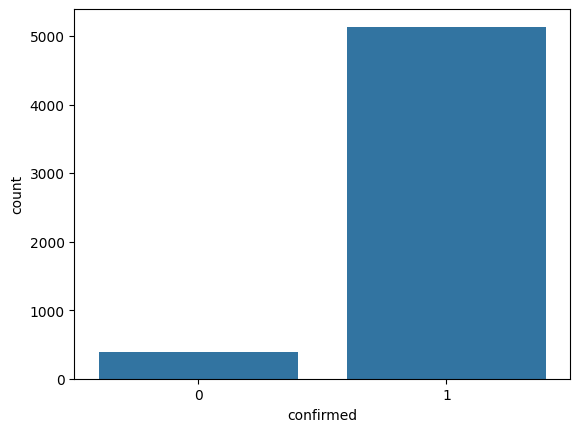

In [30]:
sns.countplot(x=df['confirmed'])

<Axes: xlabel='interview_cost_type', ylabel='count'>

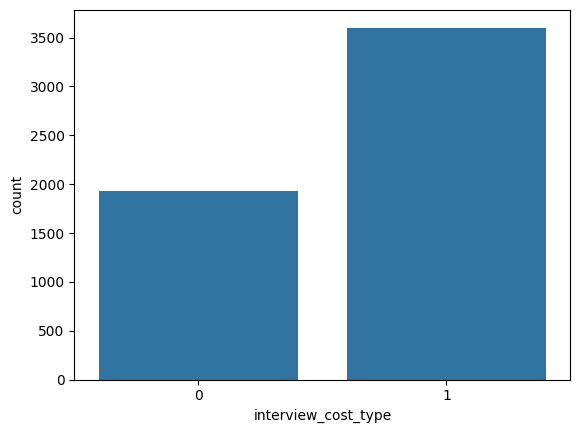

In [31]:
sns.countplot(x=df['interview_cost_type'])

<Axes: xlabel='wallet_amount', ylabel='Count'>

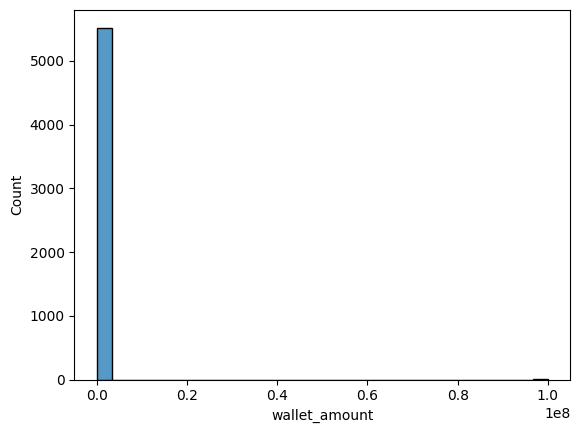

In [32]:
sns.histplot(df['wallet_amount'], bins=30)

<Axes: xlabel='subscription_amount', ylabel='Count'>

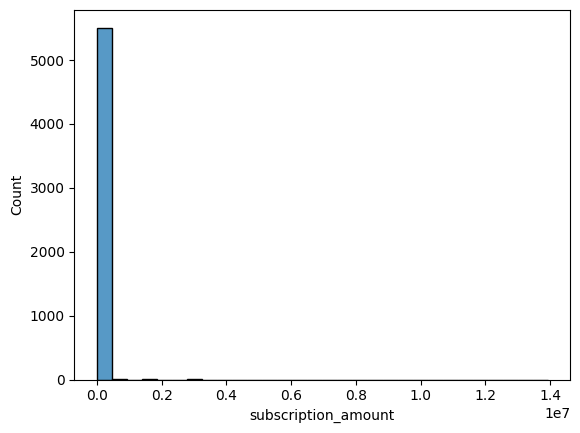

In [33]:
sns.histplot(df['subscription_amount'], bins=30)

<Axes: xlabel='days_since_creation', ylabel='Count'>

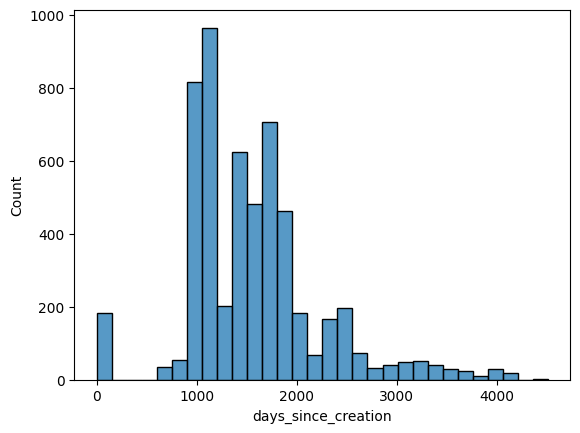

In [34]:
sns.histplot(df['days_since_creation'], bins=30)

<Axes: xlabel='pitchers_counts', ylabel='Count'>

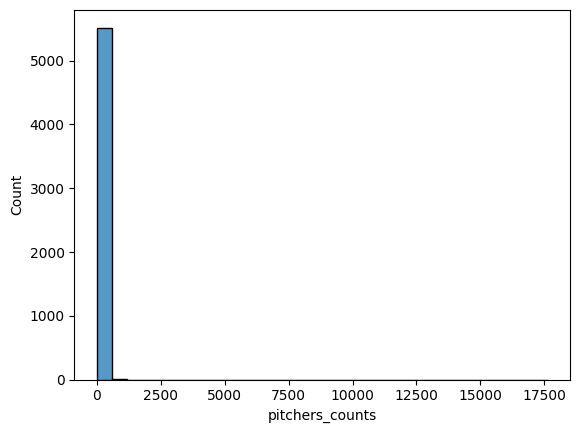

In [35]:
sns.histplot(df['pitchers_counts'], bins=30)

<Axes: xlabel='number_of_logins', ylabel='Count'>

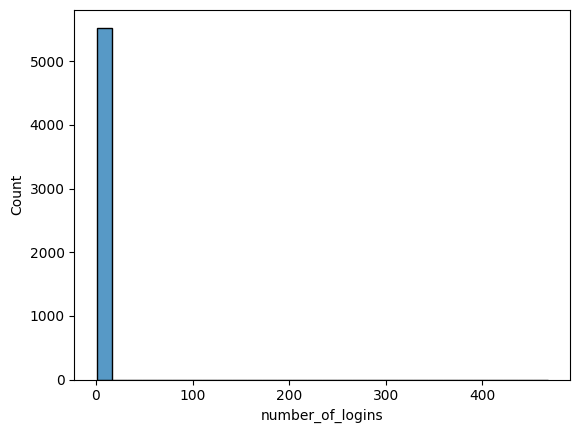

In [36]:
sns.histplot(df['number_of_logins'], bins=30)

<Axes: xlabel='kits_count', ylabel='Count'>

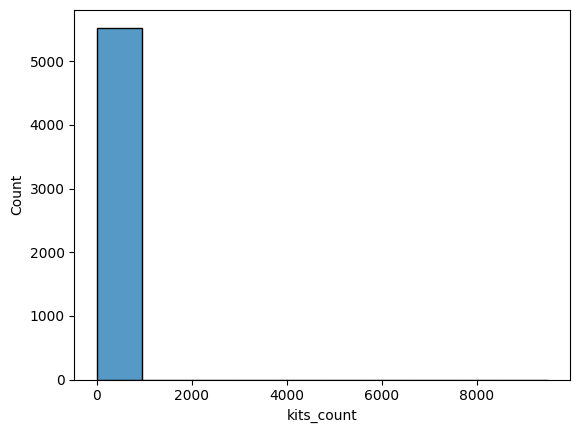

In [37]:
sns.histplot(df['kits_count'], bins=10)

<Axes: xlabel='position_created', ylabel='Count'>

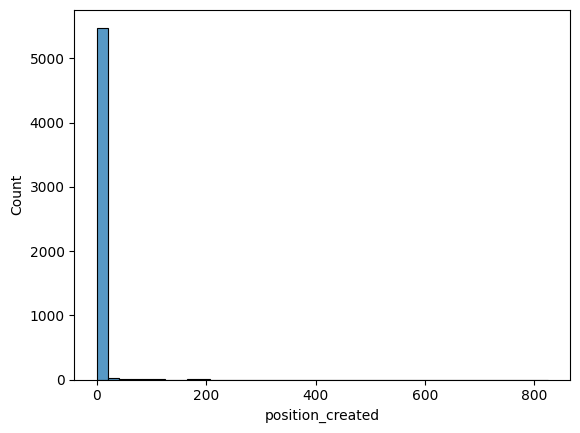

In [38]:
sns.histplot(df['position_created'], bins=40)

<Axes: xlabel='company_size', ylabel='wallet_amount'>

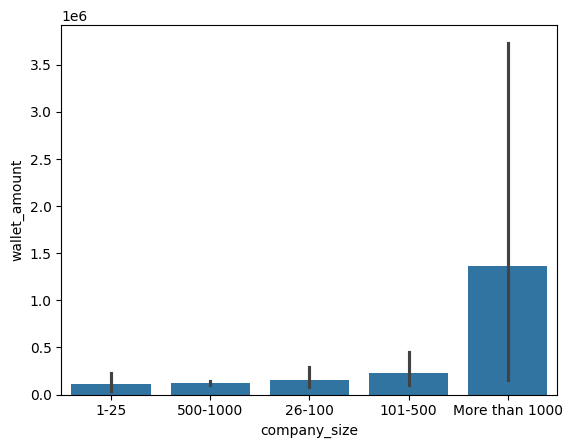

In [39]:
sns.barplot(x='company_size', y='wallet_amount', data=df)

<Axes: xlabel='company_size', ylabel='wallet_amount'>

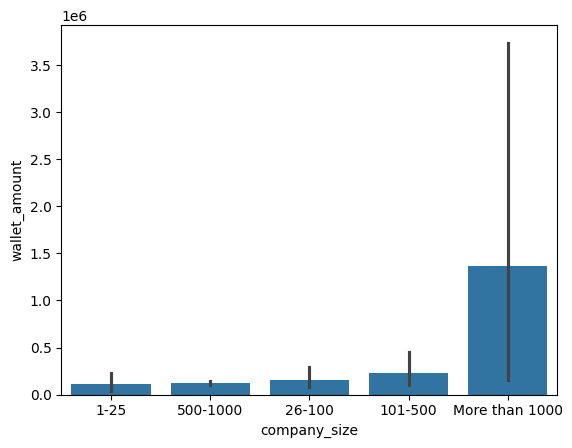

In [40]:
sns.barplot(x='company_size', y='wallet_amount', data=df)

<Axes: xlabel='subscription_amount', ylabel='is_premium'>

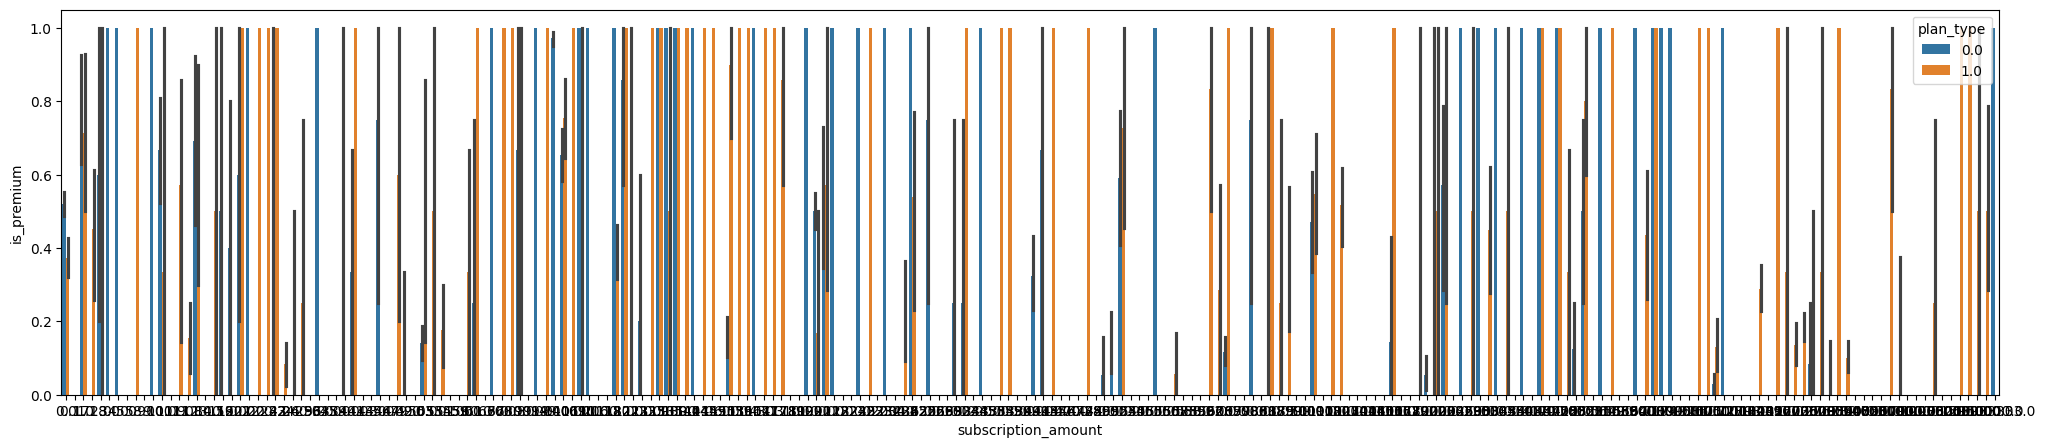

In [41]:
plt.figure(figsize=(25, 5))
sns.barplot(x='subscription_amount', y='is_premium', hue='plan_type', data=df)

<Axes: xlabel='subscription_bin', ylabel='is_premium'>

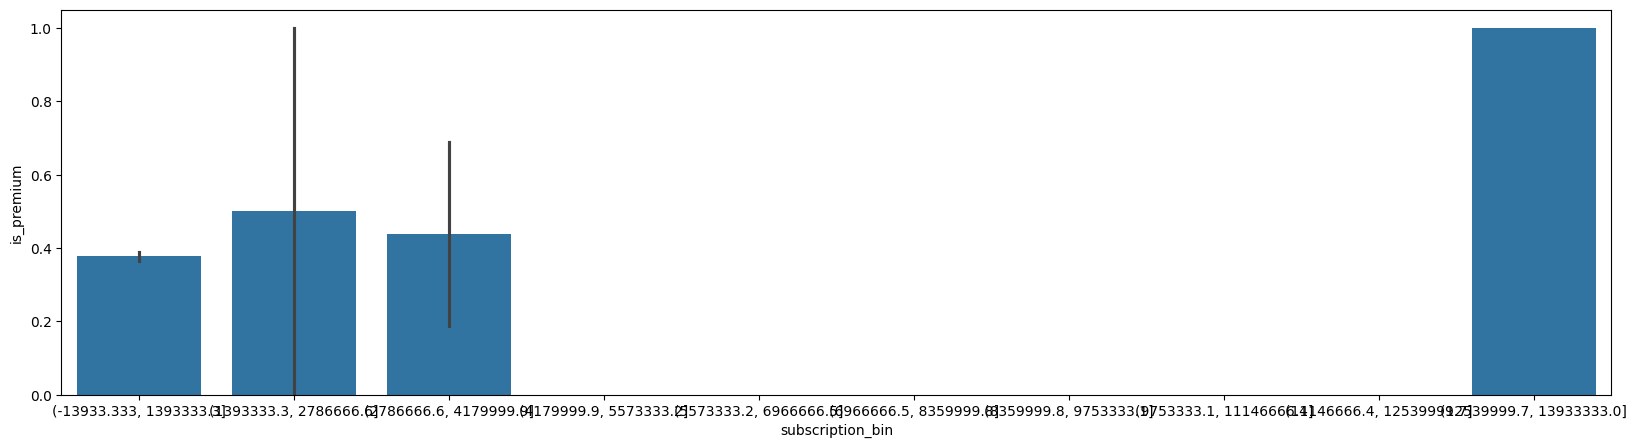

In [42]:
df['subscription_bin'] = pd.cut(df['subscription_amount'], bins=10)
plt.figure(figsize=(20,5))
sns.barplot(x='subscription_bin', y='is_premium', data=df)

<Axes: xlabel='is_premium', ylabel='wallet_amount'>

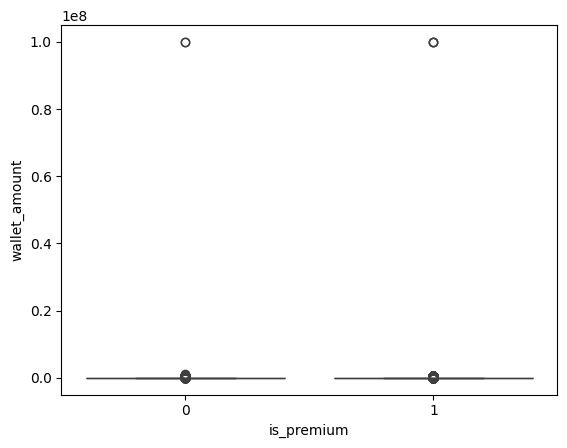

In [43]:
sns.boxplot(x='is_premium', y='wallet_amount', data=df)

In [44]:
# def cap_outliers(df, col, lower_q=0.01, upper_q=0.99):
#     lower = df[col].quantile(lower_q)
#     upper = df[col].quantile(upper_q)
#     df[col] = df[col].clip(lower, upper)
#     return df


In [45]:
df.describe()

,catcher_id,jobma_catcher_title,jobma_catcher_status,jobma_catcher_type,is_premium,jobma_verified,subscription_status,sub_user,live_interview_credit,pre_recorded_credit,...,credit_given,currency_val,times_of_subscription,kits_count,position_created,number_of_invitations,pitchers_counts,def_interview_counts,interview_counts,ai_interview_counts
count,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,...,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000
mean,4768.240369,0.234943,0.908663,0.922590,0.378188,0.999096,1.887864,279.376379,1.423505,3.383758,...,49.328269,1.977976,1.986616,2.605173,1.512751,8.709893,6.570266,3.347260,0.170194,0.013384
std,2431.388564,0.777744,0.301610,0.267265,0.484979,0.030061,0.317847,1927.332416,13.675515,135.205973,...,291.776292,8.306666,4.597021,128.021540,18.617189,102.554300,240.300559,37.065864,3.278246,0.903944
min,92.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2774.000000,0.000000,1.000000,1.000000,0.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4794.000000,0.000000,1.000000,1.000000,0.000000,1.000000,2.000000,5.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6914.000000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,103.000000,1.000000,1.000000,...,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,9445.000000,8.000000,1.000000,1.000000,1.000000,1.000000,2.000000,140000.000000,1000.000000,9999.990000,...,10000.000000,71.870000,238.000000,9504.000000,825.000000,3396.000000,17640.000000,1069.000000,150.000000,67.000000


<Axes: >

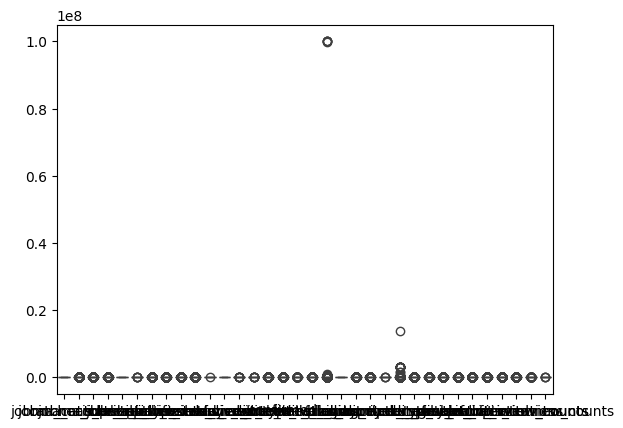

In [46]:
sns.boxplot(df)

In [47]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df[['wallet_amount', 'subscription_amount']] = scaler.fit_transform(df[['wallet_amount', 'subscription_amount']])


In [48]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
catcher_id,5529.0,4768.240369,2431.388564,92.000000,2774.000000,4794.0,6914.000000,9445.000000
jobma_catcher_title,5529.0,0.234943,0.777744,0.000000,0.000000,0.0,0.000000,8.000000
jobma_catcher_status,5529.0,0.908663,0.301610,-1.000000,1.000000,1.0,1.000000,1.000000
jobma_catcher_type,5529.0,0.922590,0.267265,0.000000,1.000000,1.0,1.000000,1.000000
is_premium,5529.0,0.378188,0.484979,0.000000,0.000000,0.0,1.000000,1.000000
jobma_verified,5529.0,0.999096,0.030061,0.000000,1.000000,1.0,1.000000,1.000000
subscription_status,5529.0,1.887864,0.317847,0.000000,2.000000,2.0,2.000000,2.000000
sub_user,5529.0,279.376379,1927.332416,0.000000,1.000000,5.0,103.000000,140000.000000
live_interview_credit,5529.0,1.423505,13.675515,0.000000,1.000000,1.0,1.000000,1000.000000
pre_recorded_credit,5529.0,3.383758,135.205973,0.000000,1.000000,1.0,1.000000,9999.990000


In [49]:
df.drop(columns=['sub_user'], inplace=True) #As it har irrelevant data and very weak correlation with other table

In [50]:
df.describe()

,catcher_id,jobma_catcher_title,jobma_catcher_status,jobma_catcher_type,is_premium,jobma_verified,subscription_status,live_interview_credit,pre_recorded_credit,ai_live_interview_credit,...,credit_given,currency_val,times_of_subscription,kits_count,position_created,number_of_invitations,pitchers_counts,def_interview_counts,interview_counts,ai_interview_counts
count,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,...,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000
mean,4768.240369,0.234943,0.908663,0.922590,0.378188,0.999096,1.887864,1.423505,3.383758,1.000181,...,49.328269,1.977976,1.986616,2.605173,1.512751,8.709893,6.570266,3.347260,0.170194,0.013384
std,2431.388564,0.777744,0.301610,0.267265,0.484979,0.030061,0.317847,13.675515,135.205973,0.013449,...,291.776292,8.306666,4.597021,128.021540,18.617189,102.554300,240.300559,37.065864,3.278246,0.903944
min,92.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2774.000000,0.000000,1.000000,1.000000,0.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4794.000000,0.000000,1.000000,1.000000,0.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6914.000000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,9445.000000,8.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1000.000000,9999.990000,2.000000,...,10000.000000,71.870000,238.000000,9504.000000,825.000000,3396.000000,17640.000000,1069.000000,150.000000,67.000000


In [51]:
df['live_interview_credit'].value_counts()

live_interview_credit
1.00       5066
0.00        185
1.50        124
15.00        62
1.33         20
2.00         18
3.00         10
16.00         9
0.10          7
50.00         5
0.67          4
5.00          4
4.00          3
10.00         3
7.00          2
1.22          1
0.50          1
0.86          1
100.00        1
1000.00       1
11.00         1
9.00          1
Name: count, dtype: int64

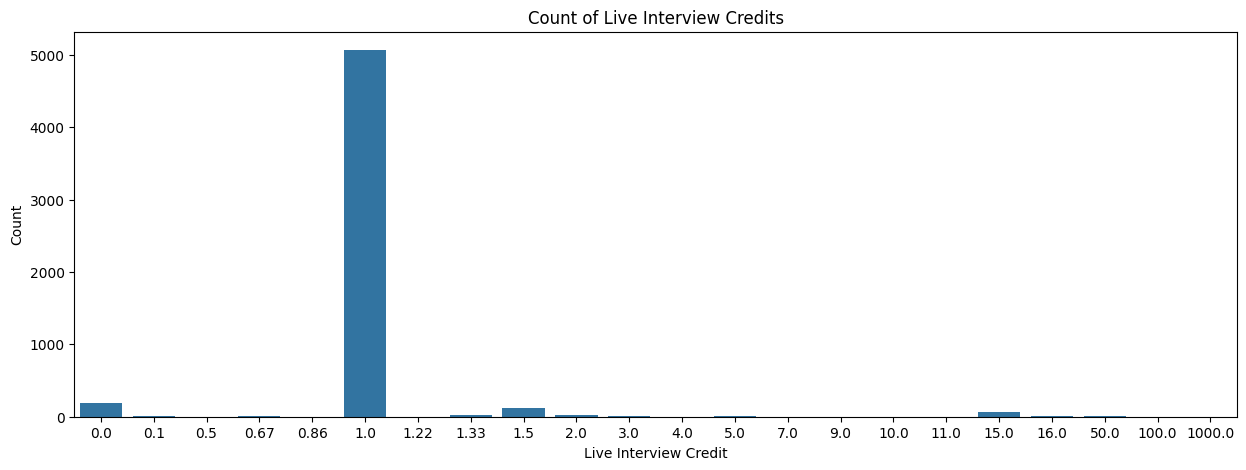

In [55]:
plt.figure(figsize=(15,5))
sns.countplot(x='live_interview_credit', data=df)
plt.title('Count of Live Interview Credits')
plt.xlabel('Live Interview Credit')
plt.ylabel('Count')
plt.show()